# Bayesian Neural Network with Hamiltorch (HMC)

Notebook prepared for training a Bayesian Neural Network with **Hamiltonian Monte Carlo** using [hamiltorch](https://github.com/AdamCobb/hamiltorch).

**How to use it:**
1. Run the **Initialization** cell.
2. Run **one** of the datasets (SINE or COMPLEX).
3. Run **HMC Sampling**.
4. Run **Prediction and Metrics** (VALIDATION and TEST).

The notebook is robust to stability issues (uses `float64`).

## Initialization and Libraries
Configure the environment, fonts, device (CPU/GPU), `float64` for stability, and seeds.

In [55]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn  # Neural network modules

import hamiltorch

from matplotlib import rc

rc("font", **{"family": "serif", "serif": ["Times New Roman"], "size": 16})

# Device and dtype in DOUBLE for greater numerical stability
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float64)

# Seeds
np.random.seed(42)
torch.manual_seed(42)

print("Device:", device)
print("Default dtype:", torch.get_default_dtype())

Device: cpu
Default dtype: torch.float64


## Model: Neural Network (1–10–10–1) with LeakyReLU
We define the architecture and prepare the initial parameters for HMC. 

Note that the **1–10–10–1** configuration is somewhat arbitrary. The architecture is designed such that the **first layer** matches the number of inputs and the **last layer** matches the number of outputs. We have chosen two hidden layers of 10 neurons each to demonstrate the model's behavior effectively without creating an overly complex network.

In [56]:
# Define the neural network class
# The Leaky ReLU is similar to a ReLU, but instead of having zero slope for negative values,
# it has a small positive slope for negative inputs
lrelu = nn.LeakyReLU(0.1)


class Net(nn.Module):
    def __init__(self, layer_sizes, loss="regression", bias=True):
        super(Net, self).__init__()
        self.layer_sizes = layer_sizes
        self.loss = loss
        self.bias = bias

        self.l1 = nn.Linear(layer_sizes[0], layer_sizes[1], bias=True)
        self.l2 = nn.Linear(layer_sizes[1], layer_sizes[2], bias=self.bias)
        self.l3 = nn.Linear(layer_sizes[2], layer_sizes[3], bias=self.bias)

    def forward(self, x):
        x = self.l1(x)
        x = lrelu(x)
        x = self.l2(x)
        x = lrelu(x)
        x = self.l3(x)
        return x


# Create the network using the class just defined
layer_sizes = [1, 10, 10, 1]
net = Net(layer_sizes).to(device, dtype=torch.float64)

# flatten(net) flattens all network parameters (weight matrices and bias vectors) into a single 1D vector.
# This vector serves as the starting point from which Hamiltonian Monte Carlo (HMC) will begin proposing parameter samples.
params_init = hamiltorch.util.flatten(net).to(device).clone()
print("Total number of parameters:", params_init.numel())

# tau_list is a prior on the parameters. It is the list of precisions {τi}, one per tensor parameter in your network.
# In this architecture with 3 linear layers there are 6 tensors: l1.weight, l1.bias, l2.weight, l2.bias, l3.weight, l3.bias
tau_list = torch.tensor(
    [1.0 for _ in net.parameters()], dtype=torch.float64, device=device
)

Total number of parameters: 141


**`tau_out`** (output noise precision): the $1/\sigma^2$ precision of the Gaussian likelihood over the observations.

If you believe the output has noise with a standard deviation $\sigma$, set `tau_out = 1 / \sigma^2`.

Examples:
* If $\sigma = 0.1 \rightarrow$ `tau_out` = 100.
* If $\sigma = 0.2 \rightarrow$ `tau_out` = 25.

**Effect:** It controls how much you trust the data versus the prior.

* **High `tau_out` (small $\sigma$):** The model "believes" the data is very precise, resulting in a tighter fit and narrower uncertainty bands.
* **Low `tau_out` (large $\sigma$):** It assumes significant noise, resulting in wider bands and less fine-tuning to the data points.

**Rule of thumb:** Use your knowledge of the dataset.
* Sine wave with 0.1 noise $\rightarrow$ 100.
* If the bands are too narrow and don't cover the ground truth well, try lowering `tau_out` (e.g., 60–80).
* If they are excessively wide, increase it (e.g., 120–200).

## DATASET 
**Sine Objective Function**



* **Train:** $y=\sin(x)+\mathcal{N}(0,0.1^2)$ within the range $[-\pi, \pi]$.
* **Validation:** $y=\sin(x)$ (noise-free) within the range $[-5,5]$.
* **Test:** $y=\sin(x)+\mathcal{N}(0,0.1^2)$ within the range $[-5,5]$.
* **Fixed `tau_out = 100`:** Precision is defined as $1/\sigma^2$ where $\sigma=0.1$.

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

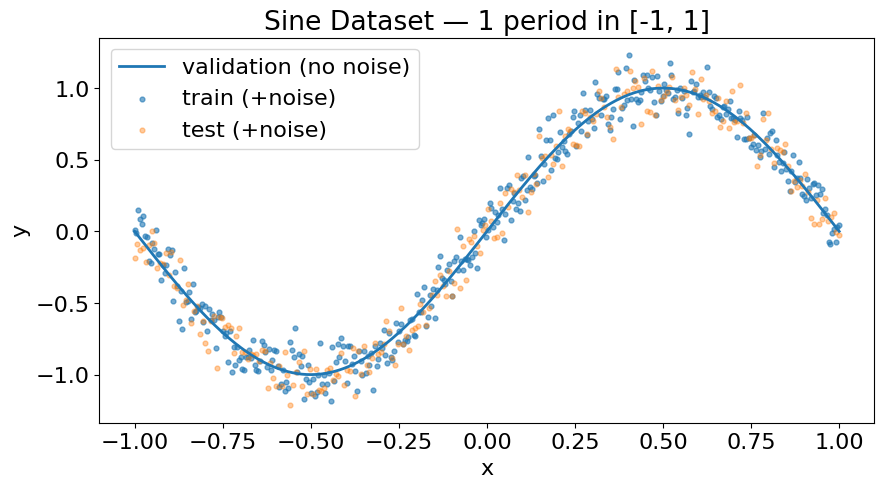

Device: cpu
Shapes — x_train, x_val, x_test: torch.Size([400, 1]) torch.Size([300, 1]) torch.Size([250, 1])
tau_out: 100.0


In [57]:
# =========================
# SINE DATASET
# y(x) = sin(pi * x)
# =========================
import torch, numpy as np, matplotlib.pyplot as plt

# Sizes
N_tr, N_val, N_test = 400, 300, 250

# Set random seeds for reproducibility (optional)
np.random.seed(7)
torch.manual_seed(7)

# Sine wave function (A=1, f=0.5, phi=0)
def f_wave(x):
    return torch.sin(torch.pi * x)  # 1 period in [-1, 1]

sigma_noise = 0.1  # noise standard deviation

# 1) TRAIN: sine with noise (visible in 1 period)
x_train = torch.linspace(-1.0, 1.0, N_tr, dtype=torch.float64).view(-1, 1)
y_train = f_wave(x_train) + torch.randn_like(x_train, dtype=torch.float64) * sigma_noise

# 2) VALIDATION: sine without noise
x_val = torch.linspace(-1.0, 1.0, N_val, dtype=torch.float64).view(-1, 1)
y_val = f_wave(x_val)

# 3) TEST: sine with noise
x_test = torch.linspace(-1.0, 1.0, N_test, dtype=torch.float64).view(-1, 1)
y_test = f_wave(x_test) + torch.randn_like(x_test, dtype=torch.float64) * sigma_noise

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(
    x_val.cpu().numpy(), y_val.cpu().numpy(), "-", label="validation (no noise)", linewidth=2
)
plt.scatter(
    x_train.cpu().numpy(),
    y_train.cpu().numpy(),
    s=12,
    alpha=0.6,
    label="train (+noise)",
)
plt.scatter(
    x_test.cpu().numpy(), y_test.cpu().numpy(), s=12, alpha=0.4, label="test (+noise)"
)
plt.legend()
plt.title("Sine Dataset — 1 period in [-1, 1]")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Move tensors to device and keep float64 (CUDA-friendly)
device = globals().get("device", ("cuda" if torch.cuda.is_available() else "cpu"))
x_train = x_train.to(device)
y_train = y_train.to(device)
x_val = x_val.to(device)
y_val = y_val.to(device)
x_test = x_test.to(device)
y_test = y_test.to(device)

# Likelihood precision (σ=0.1 → tau_out=1/σ^2=100)
tau_out = 100.0
print("Device:", device)
print("Shapes — x_train, x_val, x_test:", x_train.shape, x_val.shape, x_test.shape)
print(f"tau_out: {tau_out}")

## HMC Sampling (Robust in `float64`)

- **`num_steps_per_sample` (L):** The number of integration steps (leapfrog steps) HMC takes to propose a new sample.
    * **L too low:** Proposals move very little $\rightarrow$ high autocorrelation (samples look very similar).
    * **L too high:** Longer trajectory; if the discretization isn't fine enough, error increases and the acceptance rate drops.
    * **Rule of thumb:** Start with **L between 10–30**.

- **`step_size` ($\epsilon$):** The step size for each leapfrog integration step.
    * **Very small:** Precise integration and high acceptance, but slow (requires more steps to move across the distribution).
    * **Very large:** Abrupt jumps, low acceptance rate, or NaNs.
    * **Interaction with L:** The product $L \times \text{step\_size}$ determines the total trajectory length per proposal.
    * **Target:** Aim for an average acceptance rate around **0.6–0.8** (monitor this using `debug=1`).
    * **Rule of thumb:** If you see low acceptance or NaNs $\rightarrow$ lower the `step_size` (e.g., 0.001 $\rightarrow$ 0.0007) or lower **L**. If the chain barely moves (flat traces) $\rightarrow$ slightly increase `step_size` or **L**.



- **`num_samples`:** The total number of samples (parameter sets) to draw from the posterior.
    * **Note:** The initial samples are usually "burn-in." If you use `burn_frac = 0.5`, you will end up with approximately 50% effective samples (e.g., 450-500).
    * **Rule of thumb:** **500–2000** is usually a good starting point. If there is high autocorrelation, you will need more samples.

In [58]:
# Quick Data Diagnosis
for name, t in [("x_train", x_train), ("y_train", y_train)]:
    assert torch.isfinite(t).all(), f"{name} contains NaNs/Infs"

# HMC Hyperparameters
step_size = 0.0015
num_samples = 900
L = 12

print(f"device={device}, dtype={next(net.parameters()).dtype}")
print(f"tau_out={tau_out:.3f}, step_size={step_size}, L={L}, num_samples={num_samples}")

params_hmc = hamiltorch.sample_model(
    net,
    x_train,
    y_train,
    model_loss="regression",
    params_init=params_init,
    num_samples=num_samples,
    step_size=step_size,
    num_steps_per_sample=L,
    tau_out=tau_out,
    tau_list=tau_list,
    verbose=True,
    debug=1,
    store_on_GPU=(device == "cuda"),
)

print("Samples collected:", len(params_hmc))

device=cpu, dtype=torch.float64
tau_out=100.000, step_size=0.0015, L=12, num_samples=900
Sampling (Sampler.HMC; Integrator.IMPLICIT)
Time spent  | Time remain.| Progress             | Samples | Samples/sec
Step: 0, Current Hamiltoninian: tensor([13079.7985], grad_fn=<AddBackward0>), Proposed Hamiltoninian: tensor([13016.5617], grad_fn=<AddBackward0>)
Accept rho: 0.0
Step: 1, Current Hamiltoninian: tensor([6727.7299], grad_fn=<AddBackward0>), Proposed Hamiltoninian: tensor([6705.7857], grad_fn=<AddBackward0>)
Accept rho: 0.0
Step: 2, Current Hamiltoninian: tensor([4289.2970], grad_fn=<AddBackward0>), Proposed Hamiltoninian: tensor([4267.1621], grad_fn=<AddBackward0>)
Accept rho: 0.0
Step: 3, Current Hamiltoninian: tensor([3739.2369], grad_fn=<AddBackward0>), Proposed Hamiltoninian: tensor([3736.3516], grad_fn=<AddBackward0>)
Accept rho: 0.0
Step: 4, Current Hamiltoninian: tensor([3491.6275], grad_fn=<AddBackward0>), Proposed Hamiltoninian: tensor([3483.6052], grad_fn=<AddBackward0>)
Acc

## Quick Diagnosis: Trace Plot of the First Parameter


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

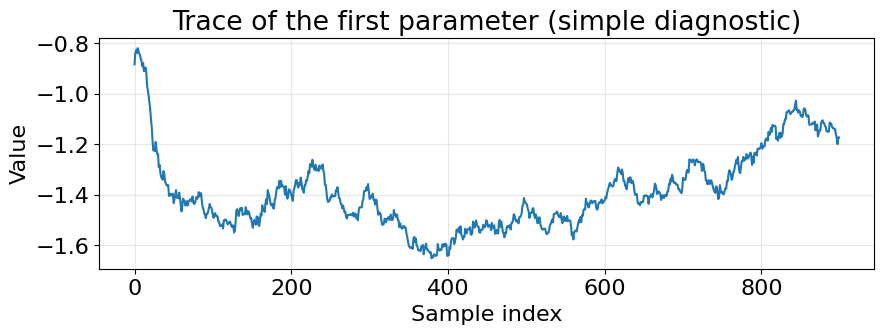

In [59]:
with torch.no_grad():
    flat = [p.detach().flatten().cpu().numpy() for p in params_hmc]
    trace_first_param = np.array([fp[0] for fp in flat])

plt.figure(figsize=(10, 3))
plt.plot(trace_first_param)
plt.title("Trace of the first parameter (simple diagnostic)")
plt.xlabel("Sample index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.show()

## Helper Function: Posterior Prediction and Metrics per Split
Calculates the posterior mean, uncertainty bands, and metrics (MSE, RMSE) for the provided data split.

In [60]:
def posterior_predict_and_metrics(
    net,
    x_split,
    y_split,
    split_name,
    *,
    params_hmc,
    tau_out,
    tau_list,
    num_samples,
    burn_frac=0.5,
    x_train=None,
    y_train=None,
    show_truth=True,
):
    """
    Predict using hamiltorch.predict_model on (x_split, y_split), plot
    sample traces/intervals and return metrics (MSE, RMSE).

    Automatically matches device/dtype to the samples.
    Supports pred_list in [S,N,1] or [S,N]. If y_split is None, does not compute metrics.
    """
    # --- 0) Device and dtype from SAMPLES (ground truth for compat) ---
    samples_device = params_hmc[0].device
    samples_dtype = params_hmc[0].dtype

    # --- 1) Move tensors to the samples' device/dtype if needed ---
    def _to_samples_dev_dtype(t):
        if t is None:
            return None
        if t.device != samples_device or t.dtype != samples_dtype:
            return t.to(device=samples_device, dtype=samples_dtype)
        return t

    x_split_sd = _to_samples_dev_dtype(x_split)
    y_split_sd = _to_samples_dev_dtype(y_split)
    tau_list_sd = _to_samples_dev_dtype(tau_list)

    # (train only used for plot scatter -> will stay on CPU later)
    x_train_cpu = None if x_train is None else x_train.detach().cpu()
    y_train_cpu = None if y_train is None else y_train.detach().cpu()

    # --- 2) Posterior prediction (on the sample device) ---
    pred_list, _ = hamiltorch.predict_model(
        net,
        x=x_split_sd,
        y=y_split_sd,
        model_loss="regression",
        samples=params_hmc[:],
        tau_out=tau_out,
        tau_list=tau_list_sd,
    )

    # --- 3) Burn-in ---
    burn = int(burn_frac * num_samples)
    pred_eff = pred_list[burn:]  # [S_eff, N, 1] or [S_eff, N]

    # --- 4) Make shape [S_eff, N] and transfer to CPU for analysis/plots ---
    pred_eff_cpu = pred_eff.detach().to("cpu")
    if pred_eff_cpu.ndim == 3:  # [S_eff, N, 1]
        pred_eff_2d = pred_eff_cpu.squeeze(-1)
    elif pred_eff_cpu.ndim == 2:  # [S_eff, N]
        pred_eff_2d = pred_eff_cpu
    else:
        raise ValueError(f"pred_eff has unexpected shape: {tuple(pred_eff_cpu.shape)}")

    # Stats (on CPU)
    mu = pred_eff_2d.mean(0).numpy()  # [N]
    sd = pred_eff_2d.std(0).numpy()   # [N]

    # Matrix [N, S_eff] for percentiles
    Y_mat = pred_eff_2d.T.numpy()     # [N, S_eff]
    p95 = np.percentile(Y_mat, 95, axis=1)
    p05 = np.percentile(Y_mat, 5, axis=1)
    p75 = np.percentile(Y_mat, 75, axis=1)
    p25 = np.percentile(Y_mat, 25, axis=1)

    xv = x_split_sd.detach().to("cpu").view(-1).numpy()
    N = xv.shape[0]
    S_eff = pred_eff_2d.shape[0]
    print(f"[{split_name}] samples_device={samples_device}, N={N}, S_eff={S_eff}")

    # --- 5) Plots (all on CPU) ---
    plt.figure(figsize=(10, 4))
    plt.plot(xv, pred_eff_2d.numpy().T, alpha=0.05)
    plt.plot(xv, mu, linewidth=2, label="Posterior mean")
    plt.plot(xv, mu + sd, linewidth=1)
    plt.plot(xv, mu - sd, linewidth=1)
    if (x_train_cpu is not None) and (y_train_cpu is not None):
        plt.scatter(
            x_train_cpu.numpy(), y_train_cpu.numpy(), s=8, alpha=0.5, label="train"
        )
    if show_truth and (y_split_sd is not None):
        plt.plot(
            xv,
            y_split_sd.detach().cpu().view(-1).numpy(),
            linewidth=1,
            label="true function",
        )
    plt.title(f"Posterior and mean ± standard deviation ({split_name})")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    if (x_train_cpu is not None) and (y_train_cpu is not None):
        plt.scatter(
            x_train_cpu.numpy(), y_train_cpu.numpy(), s=8, alpha=0.35, label="train"
        )
    plt.plot(xv, mu, linewidth=2, label="Posterior mean")
    plt.fill_between(xv, p05, p95, alpha=0.3, label="5–95%")
    plt.fill_between(xv, p25, p75, alpha=0.5, label="25–75%")
    if show_truth and (y_split_sd is not None):
        plt.plot(
            xv,
            y_split_sd.detach().cpu().view(-1).numpy(),
            linewidth=1,
            label="true function",
        )
    plt.title(f"Uncertainty bands — {split_name}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()

    # --- 6) Metrics (if y_split present) ---
    metrics = {"mu": mu, "sd": sd, "p05": p05, "p25": p25, "p75": p75, "p95": p95}
    if y_split_sd is not None:
        y_arr = y_split_sd.detach().cpu().view(-1).numpy()
        assert mu.shape == y_arr.shape, (mu.shape, y_arr.shape)
        mse = float(np.mean((mu - y_arr) ** 2))
        rmse = float(np.sqrt(mse))
        metrics.update({"mse": mse, "rmse": rmse})
        print(f"[{split_name}] MSE: {mse:.6f} | RMSE: {rmse:.6f}")
    else:
        print(f"[{split_name}] (no y) — metrics not computed")

    return metrics

## Execute Prediction and Metrics for VALIDATION and TEST
Uses the same `params_hmc` and `tau_out` for both data splits.

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

[VALIDATION] samples_device=cpu, N=300, S_eff=450


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

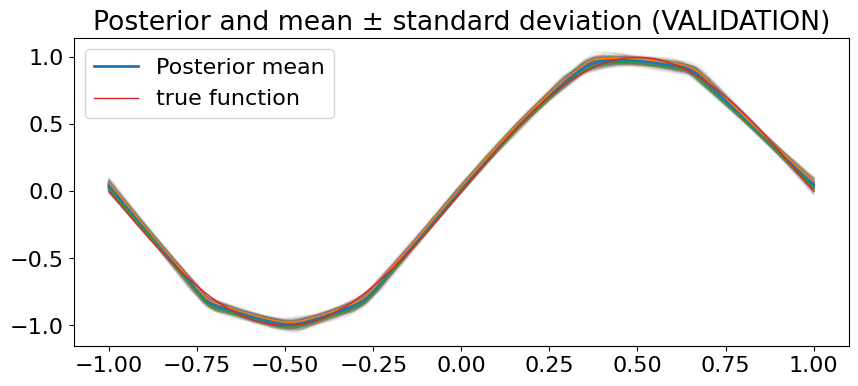

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

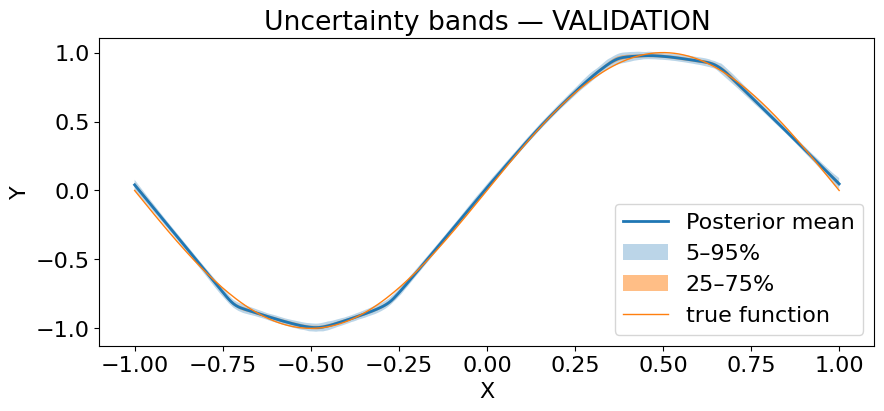

[VALIDATION] MSE: 0.000533 | RMSE: 0.023086


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

[TEST] samples_device=cpu, N=250, S_eff=450


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

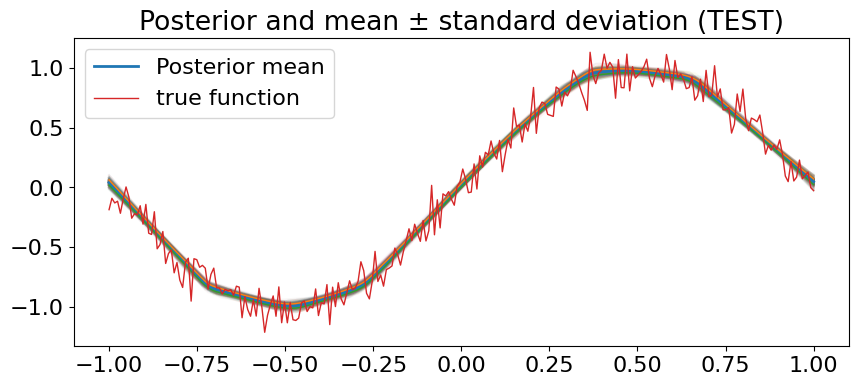

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

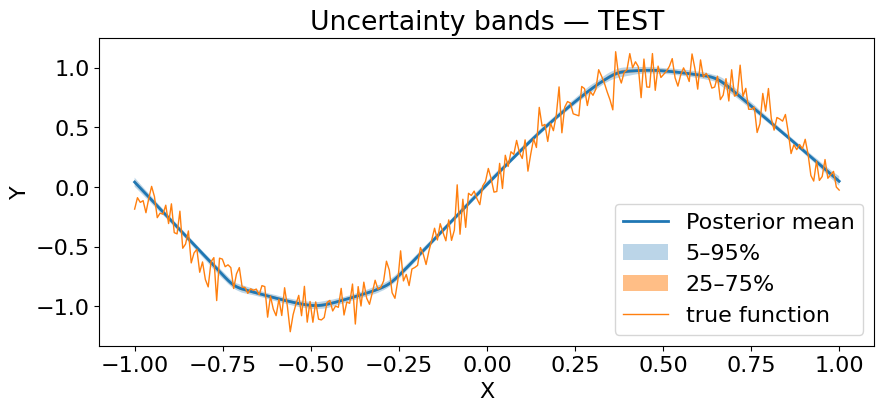

[TEST] MSE: 0.011550 | RMSE: 0.107470


In [61]:
# VALIDATION
res_val = posterior_predict_and_metrics(
    net,
    x_val,
    y_val,
    "VALIDATION",
    params_hmc=params_hmc,
    tau_out=tau_out,
    tau_list=tau_list,
    num_samples=num_samples,
    burn_frac=0.5,
)

# TEST
res_test = posterior_predict_and_metrics(
    net,
    x_test,
    y_test,
    "TEST",
    params_hmc=params_hmc,
    tau_out=tau_out,
    tau_list=tau_list,
    num_samples=num_samples,
    burn_frac=0.5,
)